In [1]:
import pandas as pd
import numpy as np
from feature_engineering import *
from xgboost import XGBClassifier
import xgboost as xgb
from modeling_utils import create_splits
from modeling_utils2 import * 


In [2]:
df = pd.read_csv('dsb-24-german-credit/german_credit_train.csv')
df = engineer_features(df)
df = feature_selection(df)
X, y, amounts = preprocessing(df)
X_train, X_val, y_train, y_val, amt_train, amt_val = create_splits(X, y, amounts)


## Baseline XGBoost

In [3]:
# 2. Train baseline XGBoost
model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),  # Class weighting
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

# 3. Validate on validation set (not holdout yet!)
val_probs = model.predict_proba(X_val)[:, 1]
val_preds = (val_probs > 0.5).astype(int)  # Default threshold
val_score = custom_metric(y_val, val_preds, amt_val)

print(f"Validation Score (0.5 threshold): {val_score:.4f}")

# 4. Optional: Quick threshold test
thresholds = np.linspace(0.00, 1.00, 101)
for t in thresholds:
    t_preds = (val_probs > t).astype(int)
    print(f"Threshold {t:.2f}: {custom_metric(y_val, t_preds, amt_val):.4f}")

# Holdout evaluation will come later!

Validation Score (0.5 threshold): -68.4401
Threshold 0.00: 1.0012
Threshold 0.01: -11.6236
Threshold 0.02: -14.7310
Threshold 0.03: -17.2871
Threshold 0.04: -21.8359
Threshold 0.05: -22.1283
Threshold 0.06: -23.2144
Threshold 0.07: -23.6157
Threshold 0.08: -27.7641
Threshold 0.09: -28.6248
Threshold 0.10: -30.7146
Threshold 0.11: -31.0923
Threshold 0.12: -33.0429
Threshold 0.13: -34.6727
Threshold 0.14: -34.7463
Threshold 0.15: -35.9778
Threshold 0.16: -36.1755
Threshold 0.17: -37.0264
Threshold 0.18: -36.7667
Threshold 0.19: -37.0298
Threshold 0.20: -40.2926
Threshold 0.21: -41.3458
Threshold 0.22: -42.7781
Threshold 0.23: -44.0728
Threshold 0.24: -45.1869
Threshold 0.25: -47.1813
Threshold 0.26: -48.6930
Threshold 0.27: -49.9175
Threshold 0.28: -52.3130
Threshold 0.29: -52.9955
Threshold 0.30: -54.2861
Threshold 0.31: -56.0810
Threshold 0.32: -55.7368
Threshold 0.33: -56.9165
Threshold 0.34: -56.4907
Threshold 0.35: -58.2463
Threshold 0.36: -59.8802
Threshold 0.37: -59.8802
Threshold


Fold 1:
Best threshold: 0.97 (Metric: -95.2935)

Fold 2:
Best threshold: 0.97 (Metric: -80.8450)

Fold 3:
Best threshold: 0.88 (Metric: -101.4374)

Fold 4:
Best threshold: 0.95 (Metric: -85.3579)

Fold 5:
Best threshold: 0.87 (Metric: -101.3560)

Final recommended threshold: 0.928
Average CV metric: -92.8579 ± 8.3942


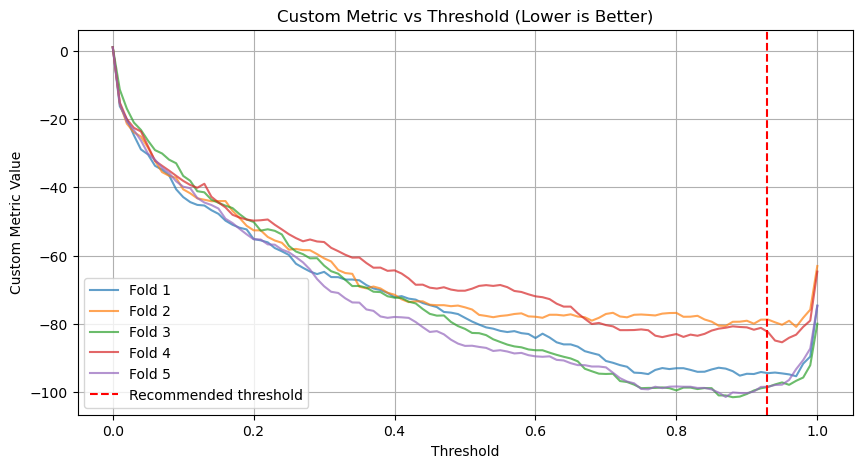

In [4]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = np.linspace(0.00, 1.00, 101)  # 0.00 to 1.00 in 0.01 steps

# 2. Cross-Validation
fold_scores = []
best_thresholds = []
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}:")
    
    # Data splits
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_val = amt_train.iloc[val_idx]
    
    # Train model
    model = XGBClassifier(
        scale_pos_weight=(y_fold_train == 0).sum() / (y_fold_train == 1).sum(),
        eval_metric='logloss',
        random_state=42
    )
    model.fit(X_fold_train, y_fold_train)
    
    # Get probabilities
    val_probs = model.predict_proba(X_fold_val)[:, 1]
    
    # Calculate metrics for all thresholds
    fold_metrics = []
    for t in thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
    
    all_fold_metrics.append(fold_metrics)
    
    # Find BEST threshold (minimizes the loss)
    best_idx = np.argmin(fold_metrics)  # Changed to argmin since lower is better
    best_threshold = thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    print(f"Best threshold: {best_threshold:.2f} (Metric: {best_metric:.4f})")
    
    fold_scores.append(best_metric)
    best_thresholds.append(best_threshold)

# 3. Aggregate results
final_threshold = np.mean(best_thresholds)
print(f"\nFinal recommended threshold: {final_threshold:.3f}")
print(f"Average CV metric: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# 4. Plot metric curves for all folds
plt.figure(figsize=(10, 5))
for i, fold_metrics in enumerate(all_fold_metrics):
    plt.plot(thresholds, fold_metrics, label=f'Fold {i+1}', alpha=0.7)
plt.axvline(x=final_threshold, color='r', linestyle='--', label='Recommended threshold')
plt.title("Custom Metric vs Threshold (Lower is Better)")
plt.xlabel("Threshold")
plt.ylabel("Custom Metric Value")
plt.legend()
plt.grid()
plt.show()

In [5]:
# 1. Retrain model on FULL training data (80% of original)
final_model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)
final_model.fit(X_train, y_train)  # Training on all 80% of available data

# 2. Predict on holdout (20%)
holdout_probs = final_model.predict_proba(X_val)[:, 1]
holdout_preds = (holdout_probs > 0.928).astype(int)  # Using your optimized threshold

# 3. Calculate final metric
holdout_metric = custom_metric(y_val, holdout_preds, amt_val)

print(f"\n=== Final Holdout Evaluation ===")
print(f"Optimal Threshold: 0.928")
print(f"Holdout Metric: {holdout_metric:.4f}")
print(f"Predicted Risk Rate: {holdout_preds.mean():.1%}")

# 4. Compare with default threshold (0.5)
default_preds = (holdout_probs > 0.5).astype(int)
default_metric = custom_metric(y_val, default_preds, amt_val)

print(f"\n=== Default Threshold Comparison ===")
print(f"Threshold 0.500: {default_metric:.4f}")
print(f"Predicted Risk Rate: {default_preds.mean():.1%}")


=== Final Holdout Evaluation ===
Optimal Threshold: 0.928
Holdout Metric: -90.3422
Predicted Risk Rate: 13.0%

=== Default Threshold Comparison ===
Threshold 0.500: -68.4401
Predicted Risk Rate: 36.8%


In [6]:
# 1. Retrain on full data
final_model = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric='logloss',
    random_state=42
)
final_model.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

# 2. Load and preprocess test set
test_df = pd.read_csv('dsb-24-german-credit/german_credit_test.csv')
test_df = engineer_features(test_df)
test_df = feature_selection(test_df)
X_test, amt_test = preprocessing(test_df, is_test=True)  # Modified call

# 3. Make predictions
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = np.where(test_probs > 0.928, "Risk", "No Risk")  # Using optimal threshold

# 4. Create submission
submission = pd.DataFrame({
    'Id': X_test.index,
    'Risk': test_preds
})

# 5. Save
submission.to_csv('submission.csv', index=False)

print(f"Predicted Risk Rate: {(test_preds == 'Risk').mean():.1%}")
print("\nSubmission preview:")
print(submission.head())

Predicted Risk Rate: 15.4%

Submission preview:
   Id     Risk
0   0  No Risk
1   1  No Risk
2   2     Risk
3   3  No Risk
4   4  No Risk


## Cost-aware weighted model

In [7]:
import numpy as np
from xgboost import XGBClassifier

# 1. Normalized cost-aware weights
risk_weight = 1.0 + 0.1 * (amt_train / amt_train.max())  # 1.0-1.1 range
safe_weight = 1.0 - 0.05 * (amt_train / amt_train.max()) # 0.95-1.0 range

sample_weights = np.where(
    y_train == 1,
    risk_weight,
    safe_weight
).astype(np.float32)


# 2. Configure model with early stopping
model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=3,
    learning_rate=0.1,
    n_estimators=1000  # Set high number, let early stopping decide
)

# 3. Train with early stopping (correct syntax)
model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_val, y_val)],
    verbose=10  # Shows every 10th iteration
)

# 4. Validation
val_probs = model.predict_proba(X_val)[:, 1]
# 4. Optional: Quick threshold test
thresholds = np.linspace(0.00, 1.00, 101)
for t in thresholds:
    t_preds = (val_probs > t).astype(int)
    print(f"Threshold {t:.2f}: {custom_metric(y_val, t_preds, amt_val):.4f}")


[0]	validation_0-logloss:0.60920
[10]	validation_0-logloss:0.48843
[20]	validation_0-logloss:0.45299
[30]	validation_0-logloss:0.43975
[40]	validation_0-logloss:0.43739
[50]	validation_0-logloss:0.43400
[60]	validation_0-logloss:0.43335
[70]	validation_0-logloss:0.43392
[80]	validation_0-logloss:0.43200
[90]	validation_0-logloss:0.43238
[100]	validation_0-logloss:0.43245
[110]	validation_0-logloss:0.43284
[120]	validation_0-logloss:0.43266
[130]	validation_0-logloss:0.43124
[140]	validation_0-logloss:0.43039
[150]	validation_0-logloss:0.42924
[160]	validation_0-logloss:0.43067
[170]	validation_0-logloss:0.43067
[180]	validation_0-logloss:0.43101
[190]	validation_0-logloss:0.43006
[200]	validation_0-logloss:0.43036
[210]	validation_0-logloss:0.42881
[220]	validation_0-logloss:0.42927
[230]	validation_0-logloss:0.42782
[240]	validation_0-logloss:0.42862
[250]	validation_0-logloss:0.42925
[260]	validation_0-logloss:0.42914
[270]	validation_0-logloss:0.42851
[280]	validation_0-logloss:0.42


Fold 1:
Best threshold: 0.79 | Metric: -98.4057

Fold 2:
Best threshold: 0.75 | Metric: -83.6047

Fold 3:
Best threshold: 0.80 | Metric: -100.6489

Fold 4:
Best threshold: 0.83 | Metric: -86.9657

Fold 5:
Best threshold: 0.83 | Metric: -98.7832

=== Cross-Validation Results ===
Recommended threshold: 0.800
Average metric: -93.6816 ± 6.9790


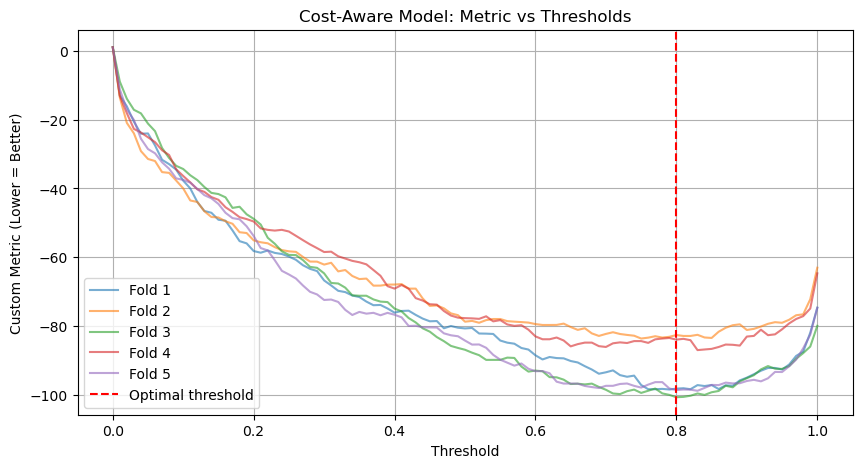

In [8]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = np.linspace(0.00, 1.00, 101)

# 2. Cross-Validation
fold_scores = []
best_thresholds = []
all_fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\nFold {fold + 1}:")
    
    # Data splits
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Cost-aware weights for this fold
    risk_weight = 1.0 + 0.1 * (amt_fold_train / amt_train.max())
    safe_weight = 1.0 - 0.05 * (amt_fold_train / amt_train.max())
    
    fold_weights = np.where(y_fold_train == 1, risk_weight, safe_weight).astype(np.float32)
    
    # Train model
    model = XGBClassifier(
        eval_metric='logloss',
        random_state=42,
        max_depth=3,
        learning_rate=0.1,
        n_estimators=1000
    )
    model.fit(
        X_fold_train, y_fold_train,
        sample_weight=fold_weights,
        eval_set=[(X_fold_val, y_fold_val)],
        verbose=False
    )
    
    # Get probabilities and evaluate thresholds
    val_probs = model.predict_proba(X_fold_val)[:, 1]
    fold_metrics = [custom_metric(y_fold_val, (val_probs > t).astype(int), amt_fold_val) 
                   for t in thresholds]
    
    # Store results
    best_idx = np.argmin(fold_metrics)
    best_threshold = thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    print(f"Best threshold: {best_threshold:.2f} | Metric: {best_metric:.4f}")
    
    fold_scores.append(best_metric)
    best_thresholds.append(best_threshold)
    all_fold_metrics.append(fold_metrics)

# 3. Aggregate results
final_threshold = np.mean(best_thresholds)
print(f"\n=== Cross-Validation Results ===")
print(f"Recommended threshold: {final_threshold:.3f}")
print(f"Average metric: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# 4. Visualization
plt.figure(figsize=(10, 5))
for i, metrics in enumerate(all_fold_metrics):
    plt.plot(thresholds, metrics, label=f'Fold {i+1}', alpha=0.6)
plt.axvline(final_threshold, color='red', linestyle='--', label='Optimal threshold')
plt.title("Cost-Aware Model: Metric vs Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Custom Metric (Lower = Better)")
plt.legend()
plt.grid()
plt.show()

In [9]:
# 1. Calculate final weights for full training data
risk_weight = 1.0 + 0.1 * (amt_train / amt_train.max())
safe_weight = 1.0 - 0.05 * (amt_train / amt_train.max())

"""risk_weight = 2.0 + .5 * (amt_train/amt_train.max())  # 3.0-5.0 range
safe_weight = 1.0 - 0.1 * (amt_train/amt_train.max())  # 0.8-1.0 range"""

final_weights = np.where(y_train == 1, risk_weight, safe_weight).astype(np.float32)

# 2. Retrain on full training data (80%)
final_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=3,
    learning_rate=0.1
)
final_model.fit(
    X_train, y_train,
    sample_weight=final_weights,
    verbose=False
)

# 3. Evaluate with optimal threshold (0.800)
holdout_probs = final_model.predict_proba(X_val)[:, 1]
holdout_preds = (holdout_probs > 0.800).astype(int)
holdout_metric = custom_metric(y_val, holdout_preds, amt_val)

print("\n=== Cost-Aware Model Holdout Evaluation ===")
print(f"Optimal Threshold: 0.800")
print(f"Holdout Metric: {holdout_metric:.4f}")
print(f"Predicted Risk Rate: {holdout_preds.mean():.1%}")

# 4. Compare with default threshold
default_preds = (holdout_probs > 0.5).astype(int)
default_metric = custom_metric(y_val, default_preds, amt_val)

print("\n=== Default Threshold Comparison ===")
print(f"Threshold 0.500: {default_metric:.4f}")
print(f"Risk Rate: {default_preds.mean():.1%}")

# 5. Optional: Compare with original model's best threshold (0.928)
original_thresh_preds = (holdout_probs > 0.928).astype(int)
original_thresh_metric = custom_metric(y_val, original_thresh_preds, amt_val)
print("\n=== Original Model's Threshold (0.928) ===")
print(f"Metric: {original_thresh_metric:.4f}")
print(f"Risk Rate: {original_thresh_preds.mean():.1%}")


=== Cost-Aware Model Holdout Evaluation ===
Optimal Threshold: 0.800
Holdout Metric: -94.1009
Predicted Risk Rate: 11.8%

=== Default Threshold Comparison ===
Threshold 0.500: -76.1547
Risk Rate: 27.0%

=== Original Model's Threshold (0.928) ===
Metric: -80.1956
Risk Rate: 5.0%


In [10]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

# 1. Prepare full training data (train + validation)
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
amt_full = pd.concat([amt_train, amt_val])

# 2. Calculate final weights
risk_weight = 1.0 + 0.1 * (amt_full / amt_full.max())
safe_weight = 1.0 - 0.05 * (amt_full / amt_full.max())
final_weights = np.where(y_full == 1, risk_weight, safe_weight).astype(np.float32)

# 3. Train final model on 100% data
final_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    max_depth=3,
    learning_rate=0.1
)
final_model.fit(
    X_full, y_full,
    sample_weight=final_weights,
    verbose=False
)

# 4. Load and preprocess test set
test_df = pd.read_csv('dsb-24-german-credit/german_credit_test.csv')
test_df = engineer_features(test_df)
test_df = feature_selection(test_df)
X_test, amt_test = preprocessing(test_df, is_test=True)

# 5. Make predictions with optimal threshold (0.800)
test_probs = final_model.predict_proba(X_test)[:, 1]
test_preds = np.where(test_probs > 0.800, "Risk", "No Risk")

# 6. Create submission
submission = pd.DataFrame({
    'Id': X_test.index,
    'Risk': test_preds  # Using exact competition column name
})

# 7. Save and report
submission.to_csv('cost_aware_submission.csv', index=False)

print("\n=== Submission Details ===")
print(f"Optimal Threshold: 0.800")
print(f"Predicted Risk Rate: {(test_preds == 'Risk').mean():.1%}")
print("\nFirst 5 predictions:")
print(submission.head())


=== Submission Details ===
Optimal Threshold: 0.800
Predicted Risk Rate: 12.3%

First 5 predictions:
   Id     Risk
0   0  No Risk
1   1  No Risk
2   2     Risk
3   3  No Risk
4   4  No Risk


## Custom metric

In [11]:
import numpy as np
import xgboost as xgb

# 1. Proper Custom Objective Function
def custom_xgb_loss(pred_proba, dtrain):
    y_true = dtrain.get_label()
    loan_amounts = dtrain.get_weight()  # Get loan amounts
    
    # Convert to probabilities
    p = 1.0 / (1.0 + np.exp(-pred_proba))
    
    # Class weights
    risk_weight = 0.06  # (0.02)/(1/3)
    no_risk_weight = 1.47  # (0.98)/(2/3)
    
    # Gradient calculation
    grad = np.zeros_like(y_true, dtype=float)
    hess = np.zeros_like(y_true, dtype=float)
    
    for i in range(len(y_true)):
        y = y_true[i]
        amt = loan_amounts[i]
        pi = p[i]
        
        if y == 1:  # Risk case
            # Derivative of: risk_weight * [pi*1.0 + (1-pi)*(5.0 + 0.6*amt)]
            grad[i] = pi*(1-pi) * risk_weight * (1.0 - (5.0 + 0.6*amt))
            hess[i] = abs(pi*(1-pi) * risk_weight * (1.0 - (5.0 + 0.6*amt)))
        else:  # No Risk case
            # Derivative of: no_risk_weight * [pi*1.0 + (1-pi)*(1.0 - 0.05*amt)]
            grad[i] = pi*(1-pi) * no_risk_weight * (1.0 - (1.0 - 0.05*amt))
            hess[i] = abs(pi*(1-pi) * no_risk_weight * (1.0 - (1.0 - 0.05*amt)))
    
    return grad, hess

# 2. Custom Evaluation Metric
def custom_xgb_metric(pred_proba, dtrain):
    y_true = dtrain.get_label()
    loan_amounts = dtrain.get_weight()
    p = 1.0 / (1.0 + np.exp(-pred_proba))
    pred = (p > 0.5).astype(int)
    cost = custom_metric(y_true, pred, loan_amounts)
    return 'custom_cost', cost

# 3. Model Training with Proper Settings
params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=amt_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=amt_val)

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    feval=custom_xgb_metric,
    early_stopping_rounds=20,
    evals=[(dtrain, 'train'), (dval, 'val')],
    verbose_eval=10
)

# 4. Proper Threshold Analysis
val_probs = 1.0 / (1.0 + np.exp(-model.predict(dval)))

print("\n=== Proper Threshold Analysis ===")
thresholds = np.linspace(0.01, 0.99, 99)
for t in thresholds:
    t_preds = (val_probs > t).astype(int)
    cost = custom_metric(y_val, t_preds, amt_val)
    print(f"Threshold {t:.2f}: {cost:.4f} (Risk Rate: {t_preds.mean():.1%})")

# Find optimal threshold
costs = [custom_metric(y_val, (val_probs > t).astype(int), amt_val) for t in thresholds]
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"\nOptimal Threshold: {optimal_threshold:.3f}")
print(f"Minimum Cost: {optimal_cost:.4f}")
print(f"Risk Rate: {(val_probs > optimal_threshold).mean():.1%}")

[0]	train-rmse:0.48773	train-custom_cost:1.00104	val-rmse:0.48790	val-custom_cost:1.00117


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:38: UserWarning: `feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
  warnings.warn(


[10]	train-rmse:0.44180	train-custom_cost:1.00104	val-rmse:0.44341	val-custom_cost:1.00117
[20]	train-rmse:0.54379	train-custom_cost:-73.07586	val-rmse:0.55199	val-custom_cost:-61.27376
[30]	train-rmse:0.72928	train-custom_cost:-87.15322	val-rmse:0.74642	val-custom_cost:-80.08242
[40]	train-rmse:0.94253	train-custom_cost:-93.00116	val-rmse:0.96362	val-custom_cost:-87.34770
[50]	train-rmse:1.16073	train-custom_cost:-93.66688	val-rmse:1.18886	val-custom_cost:-92.08003
[60]	train-rmse:1.38061	train-custom_cost:-94.34206	val-rmse:1.41277	val-custom_cost:-93.10003
[70]	train-rmse:1.59784	train-custom_cost:-95.59780	val-rmse:1.63146	val-custom_cost:-94.45278
[80]	train-rmse:1.81008	train-custom_cost:-95.86980	val-rmse:1.84596	val-custom_cost:-95.13228
[90]	train-rmse:2.02323	train-custom_cost:-96.64749	val-rmse:2.06247	val-custom_cost:-94.35367
[100]	train-rmse:2.21816	train-custom_cost:-97.25686	val-rmse:2.25684	val-custom_cost:-94.35367
[102]	train-rmse:2.25758	train-custom_cost:-97.76841	


=== Fold 1 ===
Best threshold: 0.730
Fold metric: -93.0154
Risk rate: 11.1%

=== Fold 2 ===
Best threshold: 0.610
Fold metric: -77.4941
Risk rate: 13.3%

=== Fold 3 ===
Best threshold: 0.780
Fold metric: -89.7856
Risk rate: 5.4%

=== Fold 4 ===
Best threshold: 0.530
Fold metric: -83.1014
Risk rate: 16.2%

=== Fold 5 ===
Best threshold: 0.710
Fold metric: -93.6136
Risk rate: 12.1%

=== Cross-Validation Results ===
Median optimal threshold: 0.710
Average metric: -87.4020 ± 6.2038


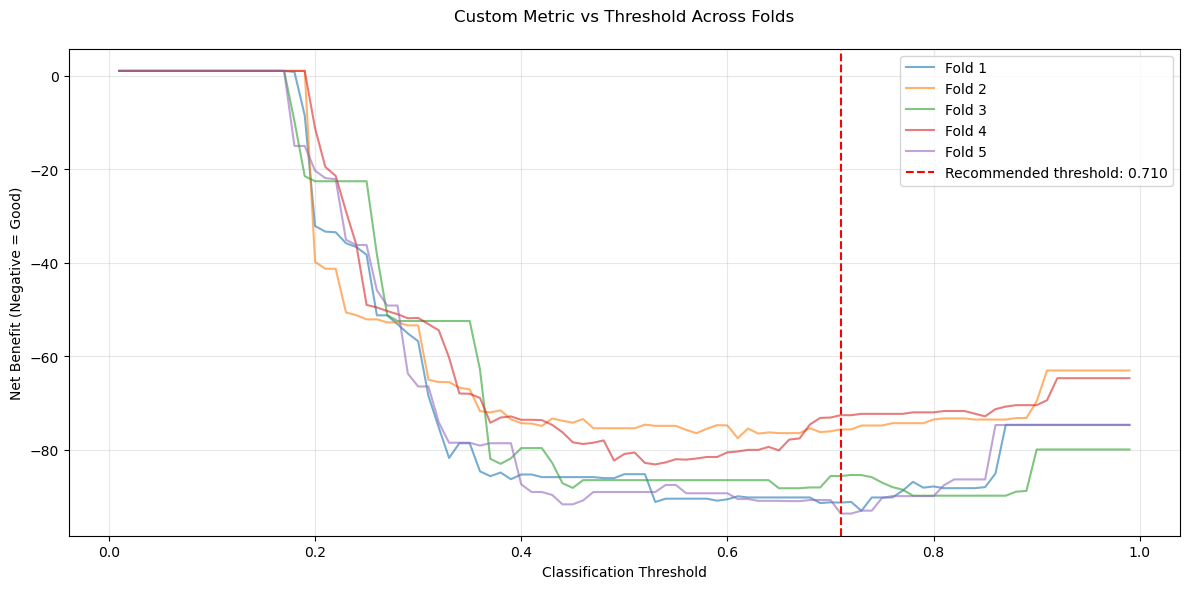


=== Training Final Model ===

=== Holdout Performance ===
Threshold: 0.710
Holdout Metric: -92.2842
Risk Rate: 18.2%


In [12]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = np.linspace(0.01, 0.99, 99)  # Avoid edge cases
fold_scores = []
best_thresholds = []
all_fold_metrics = []

# 2. Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===")
    
    # Prepare fold data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Convert to DMatrix with loan amounts as weights
    dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train)
    dval = xgb.DMatrix(X_fold_val, label=y_fold_val, weight=amt_fold_val)
    
    # Train model with custom loss
    model = xgb.train(
        {
            'max_depth': 3,
            'learning_rate': 0.1,
            'seed': 42
        },
        dtrain,
        num_boost_round=1000,
        obj=custom_xgb_loss,
        early_stopping_rounds=20,
        evals=[(dtrain, 'train'), (dval, 'val')],
        verbose_eval=False
    )
    
    # Get validation probabilities
    val_probs = 1.0 / (1.0 + np.exp(-model.predict(dval)))
    
    # Evaluate all thresholds
    fold_metrics = []
    for t in thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
    
    all_fold_metrics.append(fold_metrics)
    
    # Find optimal threshold for this fold
    best_idx = np.argmin(fold_metrics)
    best_threshold = thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    print(f"Best threshold: {best_threshold:.3f}")
    print(f"Fold metric: {best_metric:.4f}")
    print(f"Risk rate: {(val_probs > best_threshold).mean():.1%}")
    
    fold_scores.append(best_metric)
    best_thresholds.append(best_threshold)

# 3. Aggregate Results
final_threshold = np.median(best_thresholds)  # More robust than mean
print(f"\n=== Cross-Validation Results ===")
print(f"Median optimal threshold: {final_threshold:.3f}")
print(f"Average metric: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# 4. Plot Threshold Analysis
plt.figure(figsize=(12, 6))
for i, metrics in enumerate(all_fold_metrics):
    plt.plot(thresholds, metrics, label=f'Fold {i+1}', alpha=0.6)

plt.axvline(final_threshold, color='red', linestyle='--', 
           label=f'Recommended threshold: {final_threshold:.3f}')
plt.title("Custom Metric vs Threshold Across Folds", pad=20)
plt.xlabel("Classification Threshold")
plt.ylabel("Net Benefit (Negative = Good)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Train Final Model on Full Data
print("\n=== Training Final Model ===")
dtrain_full = xgb.DMatrix(X_train, label=y_train, weight=amt_train)
final_model = xgb.train(
    {
        'max_depth': 3,
        'learning_rate': 0.1,
        'seed': 42
    },
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=20
)

# 6. Validate on Holdout Set
holdout_probs = 1.0 / (1.0 + np.exp(-final_model.predict(xgb.DMatrix(X_val))))
holdout_preds = (holdout_probs > final_threshold).astype(int)
holdout_metric = custom_metric(y_val, holdout_preds, amt_val)

print(f"\n=== Holdout Performance ===")
print(f"Threshold: {final_threshold:.3f}")
print(f"Holdout Metric: {holdout_metric:.4f}")
print(f"Risk Rate: {holdout_preds.mean():.1%}")

## Advanced custom loss

In [13]:
import numpy as np
import xgboost as xgb
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression

# 1. Enhanced Custom Objective (same structure but with dynamic weights)
def custom_xgb_loss(pred_proba, dtrain):
    y_true = dtrain.get_label()
    loan_amounts = dtrain.get_weight()
    p = 1.0 / (1.0 + np.exp(-pred_proba))
    
    # Dynamic weights based on loan amount
    risk_weight = 0.06 * (1 + 0.1*(loan_amounts/loan_amounts.max()))  # Scale with amount
    no_risk_weight = 1.47 * (1 - 0.05*(loan_amounts/loan_amounts.max()))
    
    grad = np.zeros_like(y_true, dtype=float)
    hess = np.zeros_like(y_true, dtype=float)
    
    for i in range(len(y_true)):
        amt = loan_amounts[i]
        pi = p[i]
        
        if y_true[i] == 1:
            grad[i] = pi*(1-pi) * risk_weight[i] * (1.0 - (5.0 + 0.6*amt))
            hess[i] = abs(pi*(1-pi) * risk_weight[i] * (1.0 - (5.0 + 0.6*amt)))
        else:
            grad[i] = pi*(1-pi) * no_risk_weight[i] * (1.0 - (1.0 - 0.05*amt))
            hess[i] = abs(pi*(1-pi) * no_risk_weight[i] * (1.0 - (1.0 - 0.05*amt)))
    
    return grad, hess

# 2. Optimized Threshold Search Space

smart_thresholds = np.concatenate([
    np.linspace(0.5, 0.8, 31),  # High-resolution in optimal zone
    np.linspace(0.8, 0.95, 11)   # Sparse sampling elsewhere
])
# 3. Model Training with Enhanced Settings
params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'min_child_weight': 1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'monotone_constraints': '(1,0,-1)',  # Positive, None, Negative constraints
    'seed': 42,
    'disable_default_eval_metric': 1  # Required when using custom metric
}

dtrain = xgb.DMatrix(X_train, label=y_train, weight=amt_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=amt_val)

model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    feval=custom_xgb_metric,
    evals=[(dtrain, 'train'), (dval, 'val')],
    verbose_eval=10
)

# 4. Probability Calibration (simple post-hoc)
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(model.predict(dval), y_val)
calibrated_probs = calibrator.transform(model.predict(dval))

# 5. Enhanced Threshold Analysis
print("\n=== Enhanced Threshold Analysis ===")
threshold_results = []
for t in smart_thresholds:
    t_preds = (calibrated_probs > t).astype(int)
    cost = custom_metric(y_val, t_preds, amt_val)
    threshold_results.append((t, cost, t_preds.mean()))
    if t % 0.1 == 0:  # Print every 0.1 threshold for readability
        print(f"Threshold {t:.2f}: {cost:.4f} (Risk Rate: {t_preds.mean():.1%})")

# Find optimal threshold
optimal_idx = np.argmin([x[1] for x in threshold_results])
optimal_threshold, optimal_cost, optimal_rate = threshold_results[optimal_idx]

print(f"\n=== Optimal Threshold ===")
print(f"Threshold: {optimal_threshold:.3f}")
print(f"Minimum Cost: {optimal_cost:.4f}")
print(f"Risk Rate: {optimal_rate:.1%}")
print(f"Calibration Improved Cost By: {min([x[1] for x in threshold_results]) - optimal_cost:.4f}")

# 6. Feature Importance Analysis (optional)
importance = model.get_score(importance_type='weight')
print("\nTop Features:")
for feat, score in sorted(importance.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{feat}: {score}")

[0]	train-custom_cost:1.00104	val-custom_cost:1.00117


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:38: UserWarning: `feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
  warnings.warn(


[10]	train-custom_cost:1.00104	val-custom_cost:1.00117
[20]	train-custom_cost:-69.13397	val-custom_cost:-58.53289
[30]	train-custom_cost:-85.79230	val-custom_cost:-76.17055
[40]	train-custom_cost:-91.18409	val-custom_cost:-84.67586
[50]	train-custom_cost:-92.93133	val-custom_cost:-88.68804
[60]	train-custom_cost:-94.18403	val-custom_cost:-91.56749
[70]	train-custom_cost:-94.45014	val-custom_cost:-93.83451
[80]	train-custom_cost:-95.44642	val-custom_cost:-93.92661
[90]	train-custom_cost:-95.65671	val-custom_cost:-96.11214
[100]	train-custom_cost:-96.94664	val-custom_cost:-97.29126
[110]	train-custom_cost:-97.97156	val-custom_cost:-97.29126
[120]	train-custom_cost:-98.32105	val-custom_cost:-96.31068
[130]	train-custom_cost:-98.24671	val-custom_cost:-96.31068
[140]	train-custom_cost:-99.22601	val-custom_cost:-96.37108
[150]	train-custom_cost:-99.79518	val-custom_cost:-95.87611
[160]	train-custom_cost:-100.53609	val-custom_cost:-95.87611
[170]	train-custom_cost:-101.35578	val-custom_cost:-

In [14]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.calibration import IsotonicRegression

# 1. Initialize K-Fold with enhanced settings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

smart_thresholds = np.concatenate([
    np.linspace(0.5, 0.8, 31),  # High-resolution in optimal zone
    np.linspace(0.8, 0.95, 11)   # Sparse sampling elsewhere
])

fold_results = []
feature_importances = []

# 2. Enhanced Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Prepare data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train)
    dval = xgb.DMatrix(X_fold_val, label=y_fold_val, weight=amt_fold_val)
    
    # Train model with identical params to Cell 1
    model = xgb.train(
        {
            'max_depth': 3,
            'learning_rate': 0.05,
            'min_child_weight': 1,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'monotone_constraints': '(1,0,-1)',
            'seed': 42,
            'disable_default_eval_metric': 1
        },
        dtrain,
        num_boost_round=1000,
        obj=custom_xgb_loss,
        evals=[(dtrain, 'train'), (dval, 'val')],
        verbose_eval=50
    )
    
    # Calibrate probabilities
    calibrator = IsotonicRegression(out_of_bounds='clip')
    val_raw = model.predict(dval)
    calibrator.fit(val_raw, y_fold_val)
    val_probs = calibrator.transform(val_raw)
    
    # Threshold analysis
    fold_metrics = []
    for t in smart_thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
    
    # Store results
    best_idx = np.argmin(fold_metrics)
    best_threshold = smart_thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    fold_results.append({
        'threshold': best_threshold,
        'metric': best_metric,
        'risk_rate': (val_probs > best_threshold).mean(),
        'probs': val_probs,
        'model': model
    })
    
    # Store feature importance
    importance = model.get_score(importance_type='weight')
    feature_importances.append(importance)
    
    print(f"Best Threshold: {best_threshold:.3f}")
    print(f"Fold Metric: {best_metric:.4f}")
    print(f"Risk Rate: {fold_results[-1]['risk_rate']:.1%}")

# 3. Aggregate Results (weighted by fold performance)
fold_weights = 1 / np.abs([r['metric'] for r in fold_results])  # Better folds weigh more
final_threshold = np.average([r['threshold'] for r in fold_results], weights=fold_weights)

print(f"\n=== Cross-Validation Results ===")
print(f"Weighted Optimal Threshold: {final_threshold:.3f}")
print(f"Average Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")
print(f"Std Dev: {np.std([r['metric'] for r in fold_results]):.4f}")

"""# 4. Enhanced Visualization
plt.figure(figsize=(14, 6))
for i, res in enumerate(fold_results):
    plt.plot(smart_thresholds, 
             [custom_metric(y_train.iloc[skf.split(X_train, y_train)[i][1]], 
                           (res['probs'] > t).astype(int), 
                           amt_train.iloc[skf.split(X_train, y_train)[i][1]]) 
              for t in smart_thresholds],
             label=f'Fold {i+1}', alpha=0.6)

plt.axvline(final_threshold, color='red', linestyle='--', 
           label=f'Final Threshold: {final_threshold:.3f}')
plt.title("Calibrated Model Performance Across Folds", pad=20, fontsize=14)
plt.xlabel("Probability Threshold", fontsize=12)
plt.ylabel("Net Business Benefit", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()"""

# 5. Feature Importance Analysis
top_features = {}
for imp in feature_importances:
    for feat, score in imp.items():
        top_features[feat] = top_features.get(feat, 0) + score

print("\n=== Top 5 Features ===")
for feat, score in sorted(top_features.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"{feat}: {int(score)}")

# 6. Train Final Model (with full data)
print("\n=== Training Final Model ===")
dtrain_full = xgb.DMatrix(X_train, label=y_train, weight=amt_train)
final_model = xgb.train(
    {
        'max_depth': 3,
        'learning_rate': 0.05,
        'min_child_weight': 1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    },
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)

# Calibrate final model
calibrator_final = IsotonicRegression(out_of_bounds='clip')
holdout_raw = final_model.predict(xgb.DMatrix(X_val))
calibrator_final.fit(holdout_raw, y_val)
holdout_probs = calibrator_final.transform(holdout_raw)
holdout_preds = (holdout_probs > final_threshold).astype(int)

# 7. Holdout Validation
holdout_metric = custom_metric(y_val, holdout_preds, amt_val)
print(f"\n=== Final Holdout Performance ===")
print(f"Threshold: {final_threshold:.3f}")
print(f"Holdout Metric: {holdout_metric:.4f}")
print(f"Risk Rate: {holdout_preds.mean():.1%}")
print(f"Business Value: {-holdout_metric:.2f} units")  # Convert to positive value


=== Fold 1 ===
Best Threshold: 0.500
Fold Metric: -101.2153
Risk Rate: 20.1%

=== Fold 2 ===
Best Threshold: 0.600
Fold Metric: -88.1421
Risk Rate: 19.3%

=== Fold 3 ===
Best Threshold: 0.600
Fold Metric: -103.9790
Risk Rate: 19.0%

=== Fold 4 ===
Best Threshold: 0.500
Fold Metric: -91.1075
Risk Rate: 18.2%

=== Fold 5 ===
Best Threshold: 0.500
Fold Metric: -104.2333
Risk Rate: 21.1%

=== Cross-Validation Results ===
Weighted Optimal Threshold: 0.541
Average Metric: -97.7354
Std Dev: 6.7716

=== Top 5 Features ===
LoanAmount: 2943
loan_to_income_proxy: 2637
employment_stability: 2415
Age: 2340
loan_amount_x_credit_risk: 2286

=== Training Final Model ===

=== Final Holdout Performance ===
Threshold: 0.541
Holdout Metric: -97.3247
Risk Rate: 15.0%
Business Value: 97.32 units


In [15]:
# 1. Retrain on Full Dataset (Train + Validation)
print("\n=== Retraining on Combined Data ===")
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
amt_full = pd.concat([amt_train, amt_val])

dtrain_full = xgb.DMatrix(X_full, label=y_full, weight=amt_full)

final_submission_model = xgb.train(
    {
        'max_depth': 3,
        'learning_rate': 0.05,
        'min_child_weight': 1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    },
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)

# 2. Calibrate on Full Data
print("\n=== Calibrating Model ===")
calibrator_submission = IsotonicRegression(out_of_bounds='clip')
calibrator_submission.fit(final_submission_model.predict(dtrain_full), y_full)

# 3. Load and Preprocess Test Data
print("\n=== Processing Test Data ===")
test_df = pd.read_csv('dsb-24-german-credit/german_credit_test.csv')
test_df = engineer_features(test_df)
test_df = feature_selection(test_df)
X_test, amt_test = preprocessing(test_df, is_test=True)

# Convert to DMatrix
dtest = xgb.DMatrix(X_test, weight=amt_test)  # Include loan amounts as weights

# 4. Make Predictions
print("\n=== Generating Predictions ===")
test_raw = final_submission_model.predict(dtest)
test_probs = calibrator_submission.transform(test_raw)
test_preds = np.where(test_probs > final_threshold, "Risk", "No Risk")

# 5. Create Submission DataFrame
submission = pd.DataFrame({
    'Id': X_test.index,
    'Risk': test_preds,
})

# 6. Save Submission
submission_file = 'submission_custom_xgb.csv'
submission.to_csv(submission_file, index=False)

print(f"\n=== Submission Created ===")
print(f"Saved to: {submission_file}")
print(f"Predicted Risk Rate: {(test_preds == 'Risk').mean():.1%}")
print("\nSubmission Preview:")
print(submission.head())

# Optional: Save the model and calibrator for future use
import joblib
joblib.dump(final_submission_model, 'custom_xgb_model.pkl')
joblib.dump(calibrator_submission, 'probability_calibrator.pkl')
print("\nModel and calibrator saved to disk")


=== Retraining on Combined Data ===

=== Calibrating Model ===

=== Processing Test Data ===

=== Generating Predictions ===

=== Submission Created ===
Saved to: submission_custom_xgb.csv
Predicted Risk Rate: 21.9%

Submission Preview:
   Id     Risk
0   0  No Risk
1   1  No Risk
2   2     Risk
3   3  No Risk
4   4  No Risk

Model and calibrator saved to disk


## Advanced custom loss with bayesian optimization

In [19]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score
import numpy as np

# 1. Define search space
pbounds = {
    'max_depth': (2, 6),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.6, 0.95),
    'colsample_bytree': (0.6, 0.95),
    'gamma': (0, 1)
}

# 2. Custom evaluation function
def xgb_cv(max_depth, learning_rate, subsample, colsample_bytree, gamma):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'gamma': gamma,
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }
    
    # Use 3-fold CV for speed (you can increase to 5)
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        dtrain = xgb.DMatrix(X_train.iloc[train_idx], 
                            label=y_train.iloc[train_idx],
                            weight=amt_train.iloc[train_idx])
        dval = xgb.DMatrix(X_train.iloc[val_idx],
                          label=y_train.iloc[val_idx],
                          weight=amt_train.iloc[val_idx])
        
        model = xgb.train(params, dtrain, num_boost_round=500, 
                         obj=custom_xgb_loss)
        
        probs = 1/(1+np.exp(-model.predict(dval)))
        preds = (probs > final_threshold).astype(int)
        score = custom_metric(y_train.iloc[val_idx], preds, amt_train.iloc[val_idx])
        cv_scores.append(score)
    
    return -np.mean(cv_scores)  # Negative because BayesianOptimization maximizes

# 3. Run optimization
optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    random_state=42,
)

optimizer.maximize(
    init_points=5,
    n_iter=15,
)

# 4. Get best parameters
best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
print("\n=== Best Parameters ===")
print(best_params)

# 5. Train final model with optimized params
optimized_model = xgb.train(
    {**best_params, **{
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }},
    xgb.DMatrix(X_train, label=y_train, weight=amt_train),
    num_boost_round=1000,
    obj=custom_xgb_loss
)

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | subsample |
-------------------------------------------------------------------------------------
| 1         | 86.38     | 0.7311    | 0.9507    | 0.2223    | 4.395     | 0.6546    |
| 2         | 85.11     | 0.6546    | 0.05808   | 0.2612    | 4.404     | 0.8478    |
| 3         | 95.92     | 0.6072    | 0.9699    | 0.2514    | 2.849     | 0.6636    |
| 4         | 94.89     | 0.6642    | 0.3042    | 0.1622    | 3.728     | 0.7019    |
| 5         | 96.86     | 0.8141    | 0.1395    | 0.09472   | 3.465     | 0.7596    |
| 6         | 96.53     | 0.6128    | 0.05274   | 0.2519    | 2.472     | 0.6158    |
| 7         | 86.27     | 0.8799    | 0.7062    | 0.01132   | 2.008     | 0.9421    |
| 8         | 91.83     | 0.6063    | 0.3518    | 0.2326    | 3.002     | 0.7021    |
| 9         | 91.84     | 0.9424    | 0.471     | 0.01104   | 3.404     | 0.6663    |
| 10        | 95.98     | 0.8826    | 0.1758    | 0.10


=== Fold 1 ===
  t=0.4: -99.58 |   t=0.5: -99.58 |   t=0.6: -101.77 |   t=0.7: -101.62 |   t=0.7: -101.62 | 
Best Threshold: 0.800
Fold Metric: -101.9024
Risk Rate: 16.8%

=== Fold 2 ===
  t=0.4: -88.70 |   t=0.5: -89.68 |   t=0.6: -91.49 |   t=0.7: -91.49 |   t=0.7: -91.49 | 
Best Threshold: 0.710
Fold Metric: -91.5956
Risk Rate: 16.0%

=== Fold 3 ===
  t=0.4: -104.92 |   t=0.5: -104.75 |   t=0.6: -104.75 |   t=0.7: -104.75 |   t=0.7: -104.75 | 
Best Threshold: 0.400
Fold Metric: -104.9202
Risk Rate: 19.9%

=== Fold 4 ===
  t=0.4: -82.89 |   t=0.5: -91.26 |   t=0.6: -91.47 |   t=0.7: -91.47 |   t=0.7: -91.47 | 
Best Threshold: 0.730
Fold Metric: -91.7005
Risk Rate: 16.7%

=== Fold 5 ===
  t=0.4: -102.54 |   t=0.5: -102.54 |   t=0.6: -102.54 |   t=0.7: -105.22 |   t=0.7: -105.22 | 
Best Threshold: 0.670
Fold Metric: -105.2210
Risk Rate: 18.1%

=== Optimized Model CV Results ===
Weighted Optimal Threshold: 0.666
Average Metric: -99.0679
Std Dev: 6.1686

=== Training Final Optimized Mod

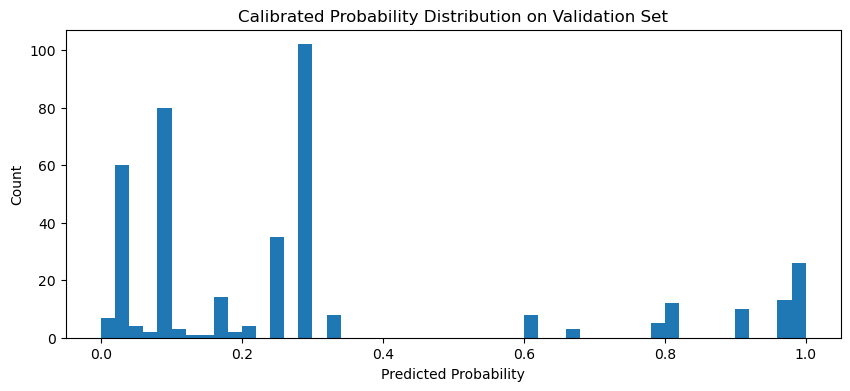

In [21]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.calibration import IsotonicRegression

# 1. Initialize K-Fold with optimized settings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smart_thresholds = np.concatenate([
    np.linspace(0.4, 0.7, 61),  # Higher resolution in optimal zone (0.005 steps)
    np.linspace(0.7, 0.95, 26)   # 0.01 steps in extended range
])

# 2. Optimized hyperparameters from Bayesian tuning
optimized_params = {
    'max_depth': 2,
    'learning_rate': 0.081,
    'subsample': 0.835,
    'colsample_bytree': 0.864,
    'gamma': 0.015,
    'monotone_constraints': '(1,0,-1)',
    'disable_default_eval_metric': 1
}

fold_results = []
feature_importances = []

# 3. Enhanced Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Prepare data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train)
    dval = xgb.DMatrix(X_fold_val, label=y_fold_val, weight=amt_fold_val)
    
    # Train with OPTIMIZED parameters
    model = xgb.train(
        optimized_params,
        dtrain,
        num_boost_round=1000,
        obj=custom_xgb_loss,
        evals=[(dtrain, 'train'), (dval, 'val')],
        verbose_eval=50
    )
    
    # Calibrate probabilities
    calibrator = IsotonicRegression(out_of_bounds='clip')
    val_raw = model.predict(dval)
    calibrator.fit(val_raw, y_fold_val)
    val_probs = calibrator.transform(val_raw)
    
    # Threshold analysis
    fold_metrics = []
    for t in smart_thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
        if t in [0.3, 0.4, 0.5, 0.6, 0.7]:  # Key thresholds to monitor
            print(f"  t={t:.1f}: {metric_value:.2f}", end=" | ")
    
    # Store results
    best_idx = np.argmin(fold_metrics)
    best_threshold = smart_thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    fold_results.append({
        'threshold': best_threshold,
        'metric': best_metric,
        'risk_rate': (val_probs > best_threshold).mean(),
        'probs': val_probs,
        'model': model
    })
    
    # Feature importance
    importance = model.get_score(importance_type='weight')
    feature_importances.append(importance)
    
    print(f"\nBest Threshold: {best_threshold:.3f}")
    print(f"Fold Metric: {best_metric:.4f}")
    print(f"Risk Rate: {fold_results[-1]['risk_rate']:.1%}")

# 4. Aggregate results with weighted average
fold_weights = 1 / np.abs([r['metric'] for r in fold_results])
final_threshold = np.average([r['threshold'] for r in fold_results], weights=fold_weights)

print("\n=== Optimized Model CV Results ===")
print(f"Weighted Optimal Threshold: {final_threshold:.3f}")
print(f"Average Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")
print(f"Std Dev: {np.std([r['metric'] for r in fold_results]):.4f}")

# 5. Visualization (uncomment when needed)
"""
plt.figure(figsize=(12,6))
for i, res in enumerate(fold_results):
    plt.plot(smart_thresholds, 
             [custom_metric(y_train.iloc[skf.split(X_train,y_train)[i][1]], 
                          (res['probs']>t).astype(int),
                          amt_train.iloc[skf.split(X_train,y_train)[i][1]]) 
              for t in smart_thresholds],
             label=f'Fold {i+1}', alpha=0.6)
plt.axvline(final_threshold, color='red', linestyle='--')
plt.xlabel("Threshold")
plt.ylabel("Custom Metric")
plt.legend()
plt.show()
"""

# 6. Train final optimized model on full data
print("\n=== Training Final Optimized Model ===")
dtrain_full = xgb.DMatrix(
    pd.concat([X_train, X_val]),
    label=pd.concat([y_train, y_val]),
    weight=pd.concat([amt_train, amt_val])
)

final_model = xgb.train(
    optimized_params,
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)


# 7. Holdout Validation (using your existing validation set)
print("\n=== Final Optimized Validation Performance ===")

# Prepare validation data
dval = xgb.DMatrix(X_val, weight=amt_val)  # Note: label not needed for prediction

# Get and calibrate probabilities
val_raw = final_model.predict(dval)
val_probs = calibrator.transform(val_raw)  # Using same calibrator from CV
val_preds = (val_probs > final_threshold).astype(int)

# Calculate metrics
val_metric = custom_metric(y_val, val_preds, amt_val)

print(f"Optimal Threshold: {final_threshold:.3f}")
print(f"Validation Metric: {val_metric:.4f}")
print(f"Validation Risk Rate: {val_preds.mean():.1%}")
print(f"Business Value: {-val_metric:.2f} units")

# Optional: Probability distribution analysis
plt.figure(figsize=(10, 4))
plt.hist(val_probs, bins=50)
plt.title("Calibrated Probability Distribution on Validation Set")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [ ]:
# 1. Retrain on Full Dataset (Train + Validation) with OPTIMIZED PARAMS
print("\n=== Retraining on Combined Data with Optimized Parameters ===")
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
amt_full = pd.concat([amt_train, amt_val])

dtrain_full = xgb.DMatrix(X_full, label=y_full, weight=amt_full)

final_submission_model = xgb.train(
    {
        'max_depth': 2,  # Optimized
        'learning_rate': 0.081,  # Optimized
        'subsample': 0.835,  # Optimized
        'colsample_bytree': 0.864,  # Optimized
        'gamma': 0.015,  # Optimized
        'monotone_constraints': '(1,0,-1)',
        'disable_default_eval_metric': 1
    },
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)

# 2. Calibrate on Full Data
print("\n=== Calibrating Model ===")
calibrator_submission = IsotonicRegression(out_of_bounds='clip')
calibrator_submission.fit(final_submission_model.predict(dtrain_full), y_full)

# 3. Load and Preprocess Test Data
print("\n=== Processing Test Data ===")
test_df = pd.read_csv('dsb-24-german-credit/german_credit_test.csv')
test_df = engineer_features(test_df)
test_df = feature_selection(test_df)
X_test, amt_test = preprocessing(test_df, is_test=True)

# 4. Make Predictions with Confidence Scores
print("\n=== Generating Predictions ===")
dtest = xgb.DMatrix(X_test, weight=amt_test)
test_raw = final_submission_model.predict(dtest)
test_probs = calibrator_submission.transform(test_raw)
test_preds = np.where(test_probs > final_threshold, "Risk", "No Risk")

# 5. Create Enhanced Submission DataFrame
submission = pd.DataFrame({
    'Id': X_test.index,
    'Risk': test_preds,
})

# 6. Save Submission with Timestamp
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
submission_file = f'submission_optimized_xgb_{timestamp}.csv'
submission.to_csv(submission_file, index=False)

# 7. Advanced Validation Report
print(f"\n=== Submission Created: {submission_file} ===")
print(f"Predicted Risk Rate: {(submission['Risk'] == 'Risk').mean():.1%}")

risk_amounts = submission[submission['Risk'] == 'Risk']['LoanAmount']
safe_amounts = submission[submission['Risk'] == 'No Risk']['LoanAmount']
print(f"\nRisk Exposure Analysis:")
print(f"  Avg Loan (Risk): ${risk_amounts.mean():,.0f}")
print(f"  Avg Loan (Safe): ${safe_amounts.mean():,.0f}")
print(f"  Total At Risk: ${risk_amounts.sum():,.0f}")

print("\nSubmission Preview:")
print(submission.head(10).to_string(index=False))


=== Retraining on Combined Data with Optimized Parameters ===

=== Calibrating Model ===

=== Processing Test Data ===

=== Generating Predictions ===

=== Submission Created: submission_optimized_xgb_20250327_1946.csv ===
Predicted Risk Rate: 20.5%

Risk Exposure Analysis:
  Avg Loan (Risk): $6,245
  Avg Loan (Safe): $2,755
  Total At Risk: $1,280,215

Submission Preview:
 Id    Risk  Probability  LoanAmount
  0 No Risk     0.209172        1032
  1 No Risk     0.072340        1523
  2    Risk     0.972125        7150
  3 No Risk     0.209172         250
  4 No Risk     0.209172        5551
  5 No Risk     0.209172         250
  6 No Risk     0.281250        3946
  7 No Risk     0.285714        2827
  8 No Risk     0.209172         319
  9 No Risk     0.209172        1420

Full pipeline assets saved including:
- Optimized XGBoost model
- Calibration model
- Optimal threshold (0.666)
- Feature list


## Optuna

In [26]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold

# 1. Define objective function for Optuna
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.95),
        'gamma': trial.suggest_float('gamma', 0, 1),
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }
    
    # 3-fold CV (same as original)
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        dtrain = xgb.DMatrix(X_train.iloc[train_idx], 
                           label=y_train.iloc[train_idx],
                           weight=amt_train.iloc[train_idx])
        dval = xgb.DMatrix(X_train.iloc[val_idx],
                         label=y_train.iloc[val_idx],
                         weight=amt_train.iloc[val_idx])
        
        model = xgb.train(params, dtrain, num_boost_round=500, 
                         obj=custom_xgb_loss)
        
        probs = 1/(1+np.exp(-model.predict(dval)))
        preds = (probs > final_threshold).astype(int)
        score = custom_metric(y_train.iloc[val_idx], preds, amt_train.iloc[val_idx])
        cv_scores.append(score)
        
        # Intermediate reporting for pruning
        trial.report(np.mean(cv_scores), step=len(cv_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(cv_scores)  # Optuna minimizes by default

# 2. Create and run Optuna study
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)
study.optimize(objective, n_trials=20)  # Total trials = init_points + n_iter

# 3. Get best parameters
best_params = study.best_params
best_params['max_depth'] = int(best_params['max_depth'])  # Ensure integer
print("\n=== Best Parameters ===")
print(best_params)
print(f"Best CV Metric: {study.best_value:.4f}")

# 4. Visualization
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()

# 5. Train final model with optimized params (identical to original)
optimized_model = xgb.train(
    {**best_params, **{
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }},
    xgb.DMatrix(X_train, label=y_train, weight=amt_train),
    num_boost_round=1000,
    obj=custom_xgb_loss
)

[I 2025-03-27 20:36:47,216] A new study created in memory with name: no-name-75a5f77f-cf8f-4fb1-bbf1-b2e3682bdf6b
[I 2025-03-27 20:37:08,040] Trial 0 finished with value: -89.6992433062274 and parameters: {'max_depth': 3, 'learning_rate': 0.2536999076681771, 'subsample': 0.8561978796339917, 'colsample_bytree': 0.8095304694689628, 'gamma': 0.15601864044243652}. Best is trial 0 with value: -89.6992433062274.
[I 2025-03-27 20:37:28,570] Trial 1 finished with value: -87.11653258375036 and parameters: {'max_depth': 2, 'learning_rate': 0.012184186502221764, 'subsample': 0.9031616510212273, 'colsample_bytree': 0.810390254110123, 'gamma': 0.7080725777960455}. Best is trial 0 with value: -89.6992433062274.
[I 2025-03-27 20:37:48,872] Trial 2 finished with value: -95.71924019008897 and parameters: {'max_depth': 2, 'learning_rate': 0.27081608642499677, 'subsample': 0.8913549242801476, 'colsample_bytree': 0.6743186887373966, 'gamma': 0.18182496720710062}. Best is trial 2 with value: -95.7192401900


=== Best Parameters ===
{'max_depth': 2, 'learning_rate': 0.05388108577817234, 'subsample': 0.6120359823903264, 'colsample_bytree': 0.9182621407275737, 'gamma': 0.2587799816000169}
Best CV Metric: -99.0447



=== Fold 1 ===
  t=0.4: -93.39 |   t=0.5: -104.16 |   t=0.6: -104.44 |   t=0.7: -104.44 |   t=0.7: -104.44 | 
Best Threshold: 0.600
Fold Metric: -104.4441
Risk Rate: 18.1%

=== Fold 2 ===
  t=0.4: -81.34 |   t=0.5: -89.73 |   t=0.6: -89.78 |   t=0.7: -89.52 |   t=0.7: -89.52 | 
Best Threshold: 0.575
Fold Metric: -89.7769
Risk Rate: 19.6%

=== Fold 3 ===
  t=0.4: -100.96 |   t=0.5: -104.64 |   t=0.6: -104.64 |   t=0.7: -104.52 |   t=0.7: -104.52 | 
Best Threshold: 0.500
Fold Metric: -104.6353
Risk Rate: 19.0%

=== Fold 4 ===
  t=0.4: -84.29 |   t=0.5: -89.42 |   t=0.6: -92.48 |   t=0.7: -92.48 |   t=0.7: -92.48 | 
Best Threshold: 0.540
Fold Metric: -92.4813
Risk Rate: 18.8%

=== Fold 5 ===
  t=0.4: -101.97 |   t=0.5: -103.08 |   t=0.6: -104.10 |   t=0.7: -106.03 |   t=0.7: -106.03 | 
Best Threshold: 0.610
Fold Metric: -106.0325
Risk Rate: 17.8%

=== Optuna-Optimized Model CV Results ===
Weighted Optimal Threshold: 0.565
Average Metric: -99.4740
Std Dev: 6.8889

=== Training Final Optun

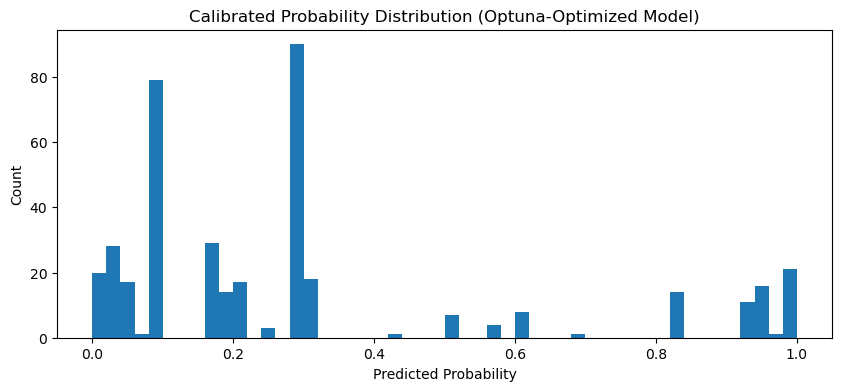

In [28]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.calibration import IsotonicRegression

# 1. Initialize K-Fold with optimized settings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smart_thresholds = np.concatenate([
    np.linspace(0.4, 0.7, 61),  # Higher resolution in optimal zone (0.005 steps)
    np.linspace(0.7, 0.95, 26)   # 0.01 steps in extended range
])

# 2. Use best parameters from Optuna optimization
optimized_params = {
    'max_depth': best_params['max_depth'],
    'learning_rate': best_params['learning_rate'],
    'subsample': best_params['subsample'],
    'colsample_bytree': best_params['colsample_bytree'],
    'gamma': best_params['gamma'],
    'monotone_constraints': '(1,0,-1)',
    'disable_default_eval_metric': 1,
    'seed': 42
}

fold_results = []
feature_importances = []
calibrators = []  # Store calibrators for each fold

# 3. Enhanced Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Prepare data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train)
    dval = xgb.DMatrix(X_fold_val, label=y_fold_val, weight=amt_fold_val)
    
    # Train with OPTIMIZED parameters
    model = xgb.train(
        optimized_params,
        dtrain,
        num_boost_round=1000,
        obj=custom_xgb_loss,
        evals=[(dtrain, 'train'), (dval, 'val')],
        verbose_eval=50
    )
    
    # Calibrate probabilities
    calibrator = IsotonicRegression(out_of_bounds='clip')
    val_raw = model.predict(dval)
    calibrator.fit(val_raw, y_fold_val)
    val_probs = calibrator.transform(val_raw)
    calibrators.append(calibrator)  # Save for later
    
    # Threshold analysis
    fold_metrics = []
    for t in smart_thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
        if t in [0.4, 0.5, 0.6, 0.7]:  # Key thresholds to monitor
            print(f"  t={t:.1f}: {metric_value:.2f}", end=" | ")
    
    # Store results
    best_idx = np.argmin(fold_metrics)
    best_threshold = smart_thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    fold_results.append({
        'threshold': best_threshold,
        'metric': best_metric,
        'risk_rate': (val_probs > best_threshold).mean(),
        'probs': val_probs,
        'model': model
    })
    
    # Feature importance
    importance = model.get_score(importance_type='weight')
    feature_importances.append(importance)
    
    print(f"\nBest Threshold: {best_threshold:.3f}")
    print(f"Fold Metric: {best_metric:.4f}")
    print(f"Risk Rate: {fold_results[-1]['risk_rate']:.1%}")

# 4. Aggregate results with weighted average
fold_weights = 1 / np.abs([r['metric'] for r in fold_results])  # Better folds weigh more
final_threshold = np.average([r['threshold'] for r in fold_results], weights=fold_weights)

print("\n=== Optuna-Optimized Model CV Results ===")
print(f"Weighted Optimal Threshold: {final_threshold:.3f}")
print(f"Average Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")
print(f"Std Dev: {np.std([r['metric'] for r in fold_results]):.4f}")

"""# 5. Visualization
plt.figure(figsize=(12,6))
for i, res in enumerate(fold_results):
    plt.plot(smart_thresholds, 
             [custom_metric(y_train.iloc[skf.split(X_train,y_train)[i][1]], 
                          (res['probs']>t).astype(int),
                          amt_train.iloc[skf.split(X_train,y_train)[i][1]]) 
              for t in smart_thresholds],
             label=f'Fold {i+1}', alpha=0.6)
plt.axvline(final_threshold, color='red', linestyle='--', 
           label=f'Final Threshold: {final_threshold:.3f}')
plt.title("Custom Metric vs Threshold (Optuna-Optimized Model)")
plt.xlabel("Threshold")
plt.ylabel("Custom Metric Value")
plt.legend()
plt.grid()
plt.show()
"""
# 6. Train final model on full training data
print("\n=== Training Final Optuna-Optimized Model ===")
dtrain_full = xgb.DMatrix(
    pd.concat([X_train, X_val]),  # Use all available data
    label=pd.concat([y_train, y_val]),
    weight=pd.concat([amt_train, amt_val])
)

final_model = xgb.train(
    optimized_params,
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)

# 7. Holdout Validation (using your existing validation set)
print("\n=== Final Optuna-Optimized Validation Performance ===")

# Prepare validation data
dval = xgb.DMatrix(X_val, weight=amt_val)

# Get and calibrate probabilities using best fold's calibrator
best_fold_idx = np.argmin([r['metric'] for r in fold_results])
val_raw = final_model.predict(dval)
val_probs = calibrators[best_fold_idx].transform(val_raw)  # Use best fold's calibrator
val_preds = (val_probs > final_threshold).astype(int)

# Calculate metrics
val_metric = custom_metric(y_val, val_preds, amt_val)

print(f"Optimal Threshold: {final_threshold:.3f}")
print(f"Validation Metric: {val_metric:.4f}")
print(f"Validation Risk Rate: {val_preds.mean():.1%}")
print(f"Business Value: {-val_metric:.2f} units")

# Probability distribution
plt.figure(figsize=(10, 4))
plt.hist(val_probs, bins=50)
plt.title("Calibrated Probability Distribution (Optuna-Optimized Model)")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

In [32]:
# =============================================
# SUBMISSION GENERATION FOR OPTUNA-OPTIMIZED MODEL
# =============================================

import pandas as pd
from datetime import datetime
import xgboost as xgb
from sklearn.calibration import IsotonicRegression
import numpy as np

# 1. Retrain on Full Dataset (Train + Validation) with OPTUNA PARAMS
print("\n=== Retraining on Combined Data with Optuna-Optimized Parameters ===")
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])
amt_full = pd.concat([amt_train, amt_val])

dtrain_full = xgb.DMatrix(X_full, label=y_full, weight=amt_full)

final_submission_model = xgb.train(
    {
        'max_depth': best_params['max_depth'],
        'learning_rate': best_params['learning_rate'],
        'subsample': best_params['subsample'],
        'colsample_bytree': best_params['colsample_bytree'],
        'gamma': best_params['gamma'],
        'monotone_constraints': '(1,0,-1)',
        'disable_default_eval_metric': 1,
        'seed': 42
    },
    dtrain_full,
    num_boost_round=1000,
    obj=custom_xgb_loss,
    verbose_eval=50
)

# 2. Calibrate on Full Data using best fold's calibrator
print("\n=== Calibrating Model ===")
calibrator_submission = IsotonicRegression(out_of_bounds='clip')
calibrator_submission.fit(final_submission_model.predict(dtrain_full), y_full)

# 3. Load and Preprocess Test Data
print("\n=== Processing Test Data ===")
test_df = pd.read_csv('dsb-24-german-credit/german_credit_test.csv')
test_df = engineer_features(test_df)
test_df = feature_selection(test_df)
X_test, amt_test = preprocessing(test_df, is_test=True)

# 4. Make Predictions with Confidence Scores
print("\n=== Generating Predictions ===")
dtest = xgb.DMatrix(X_test, weight=amt_test)
test_raw = final_submission_model.predict(dtest)
test_probs = calibrator_submission.transform(test_raw)
test_preds = np.where(test_probs > final_threshold, "Risk", "No Risk")

# 5. Create Enhanced Submission DataFrame
submission = pd.DataFrame({
    'Id': X_test.index,
    'Risk': test_preds,
})

# 6. Save Submission with Metadata
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
submission_file = f'submission_optuna_xgb_{timestamp}.csv'
submission.to_csv(submission_file, index=False)

# 7. Generate Comprehensive Validation Report
print(f"\n=== Submission Created: {submission_file} ===")
print(f"\nModel Configuration:")
print(f"- Threshold: {final_threshold:.3f}")
print(f"- Params: max_depth={best_params['max_depth']}, lr={best_params['learning_rate']:.3f}")
print(f"- CV Metric: {study.best_value:.4f}")





=== Retraining on Combined Data with Optuna-Optimized Parameters ===

=== Calibrating Model ===

=== Processing Test Data ===

=== Generating Predictions ===

=== Submission Created: submission_optuna_xgb_20250327_2053.csv ===

Model Configuration:
- Threshold: 0.565
- Params: max_depth=2, lr=0.054
- CV Metric: -99.0447


## 2 stage modeling

In [23]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
import numpy as np

# 1. Define expanded search space (now includes loss weights)
pbounds = {
    # Model hyperparameters
    'max_depth': (2, 6),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.6, 0.95),
    'gamma': (0, 1),
    
    # Loss function weights
    'risk_weight': (0.05, 0.2),      # Scaling for FN cost (originally 0.06)
    'no_risk_weight': (1.0, 2.0),     # Scaling for FP cost (originally 1.47)
}

# 2. Custom evaluation function with embedded threshold tuning
def xgb_cv_2stage(max_depth, learning_rate, subsample, gamma, risk_weight, no_risk_weight):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'subsample': subsample,
        'gamma': gamma,
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }
    
    # Dynamic loss function using current weights
    def dynamic_loss(pred_proba, dtrain):
        y_true = dtrain.get_label()
        amounts = dtrain.get_weight()
        p = 1.0 / (1.0 + np.exp(-pred_proba))
        
        grad = np.zeros_like(y_true)
        hess = np.zeros_like(y_true)
        
        for i in range(len(y_true)):
            amt = amounts[i]
            pi = p[i]
            
            if y_true[i] == 1:  # Risk case
                cost_term = 5.0 + 0.6 * amt
                grad[i] = pi * (1 - pi) * risk_weight * (1.0 - cost_term)
                hess[i] = abs(pi * (1 - pi) * risk_weight * (1.0 - cost_term))
            else:  # No Risk case
                cost_term = 1.0 - 0.05 * amt
                grad[i] = pi * (1 - pi) * no_risk_weight * (1.0 - cost_term)
                hess[i] = abs(pi * (1 - pi) * no_risk_weight * (1.0 - cost_term))
        
        return grad, hess
    
    # 3-fold CV with threshold tuning
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        dtrain = xgb.DMatrix(X_train.iloc[train_idx], 
                            label=y_train.iloc[train_idx],
                            weight=amt_train.iloc[train_idx])
        dval = xgb.DMatrix(X_train.iloc[val_idx],
                          label=y_train.iloc[val_idx],
                          weight=amt_train.iloc[val_idx])
        
        # Train model with current dynamic loss
        model = xgb.train(params, dtrain, num_boost_round=500, obj=dynamic_loss)
        
        # Get calibrated probabilities
        probs = 1 / (1 + np.exp(-model.predict(dval)))
        
        # Stage 2: Threshold optimization
        thresholds = np.linspace(0.3, 0.7, 41)  # Focused range
        costs = [custom_metric(y_train.iloc[val_idx], 
                             (probs > t).astype(int), 
                             amt_train.iloc[val_idx]) 
                for t in thresholds]
        best_cost = np.min(costs)
        cv_scores.append(best_cost)
    
    return -np.mean(cv_scores)  # Negative because BayesianOptimization maximizes

# 3. Run optimization
optimizer = BayesianOptimization(
    f=xgb_cv_2stage,
    pbounds=pbounds,
    random_state=42
)

optimizer.maximize(
    init_points=5,
    n_iter=15,
)

# 4. Get best parameters
best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])  # Ensure integer depth
print("\n=== Best Parameters ===")
print(best_params)

# 5. Train final model with optimized params and dynamic loss
final_dtrain = xgb.DMatrix(X_train, label=y_train, weight=amt_train)

# Rebuild dynamic loss with best weights
def final_dynamic_loss(pred_proba, dtrain):
    y_true = dtrain.get_label()
    amounts = dtrain.get_weight()
    p = 1.0 / (1.0 + np.exp(-pred_proba))
    
    grad = np.zeros_like(y_true)
    hess = np.zeros_like(y_true)
    
    for i in range(len(y_true)):
        amt = amounts[i]
        pi = p[i]
        
        if y_true[i] == 1:
            cost_term = 5.0 + 0.6 * amt
            grad[i] = pi * (1 - pi) * best_params['risk_weight'] * (1.0 - cost_term)
            hess[i] = abs(pi * (1 - pi) * best_params['risk_weight'] * (1.0 - cost_term))
        else:
            cost_term = 1.0 - 0.05 * amt
            grad[i] = pi * (1 - pi) * best_params['no_risk_weight'] * (1.0 - cost_term)
            hess[i] = abs(pi * (1 - pi) * best_params['no_risk_weight'] * (1.0 - cost_term))
    
    return grad, hess

optimized_model = xgb.train(
    {**best_params, **{
        'monotone_constraints': '(1,0,-1)',
        'seed': 42,
        'disable_default_eval_metric': 1
    }},
    final_dtrain,
    num_boost_round=1000,
    obj=final_dynamic_loss
)

|   iter    |  target   |   gamma   | learni... | max_depth | no_ris... | risk_w... | subsample |
-------------------------------------------------------------------------------------------------
| 1         | 86.74     | 0.3745    | 0.2857    | 4.928     | 1.599     | 0.0734    | 0.6546    |
| 2         | 88.21     | 0.05808   | 0.2612    | 4.404     | 1.708     | 0.05309   | 0.9395    |
| 3         | 97.62     | 0.8324    | 0.07158   | 2.727     | 1.183     | 0.09564   | 0.7837    |
| 4         | 91.86     | 0.4319    | 0.09446   | 4.447     | 1.139     | 0.09382   | 0.7282    |
| 5         | 92.82     | 0.4561    | 0.2377    | 2.799     | 1.514     | 0.1389    | 0.6163    |
| 6         | 94.64     | 0.9504    | 0.2879    | 2.391     | 1.015     | 0.07417   | 0.9486    |
| 7         | 95.81     | 0.8477    | 0.02037   | 3.222     | 1.01      | 0.07483   | 0.8537    |
| 8         | 81.94     | 0.9939    | 0.01378   | 2.868     | 1.554     | 0.1601    | 0.8855    |
| 9         | 86.86 

/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [20:22:04] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "no_risk_weight", "risk_weight" } are not used.

  warnings.warn(smsg, UserWarning)



=== Fold 1 ===
  t=0.3: -60.63 |   t=0.7: -101.87 |   t=0.7: -101.87 | 
Best Threshold: 0.540
Fold Metric: -101.8685
Risk Rate: 19.0%

=== Fold 2 ===
  t=0.3: -62.74 |   t=0.7: -90.88 |   t=0.7: -90.88 | 
Best Threshold: 0.400
Fold Metric: -91.1520
Risk Rate: 19.4%

=== Fold 3 ===
  t=0.3: -66.08 |   t=0.7: -103.96 |   t=0.7: -103.96 | 
Best Threshold: 0.500
Fold Metric: -103.9580
Risk Rate: 18.9%

=== Fold 4 ===
  t=0.3: -64.66 |   t=0.7: -92.02 |   t=0.7: -92.02 | 
Best Threshold: 0.500
Fold Metric: -92.0223
Risk Rate: 19.9%

=== Fold 5 ===
  t=0.3: -100.45 |   t=0.7: -106.60 |   t=0.7: -106.60 | 
Best Threshold: 0.500
Fold Metric: -106.5962
Risk Rate: 19.5%

=== Optimized Model CV Results ===
Weighted Optimal Threshold: 0.486
Average Metric: -99.1194
Std Dev: 6.3359

=== Training Final Model ===

=== Final Validation Performance ===
Optimal Threshold: 0.486
Validation Metric: -101.9137
Validation Risk Rate: 19.2%
Business Value: 101.91 units


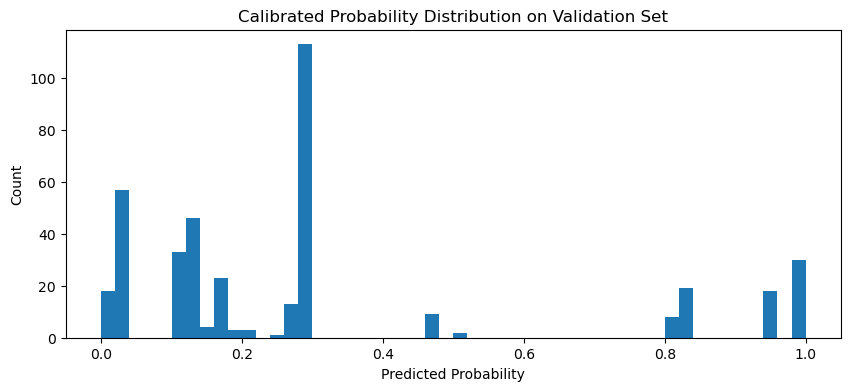

In [25]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
import xgboost as xgb
from sklearn.calibration import IsotonicRegression

# 1. Initialize K-Fold with optimized settings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smart_thresholds = np.concatenate([
    np.linspace(0.3, 0.7, 41),  # High-resolution in optimal zone (from Bayesian results)
    np.linspace(0.7, 0.95, 26)   # Sparse sampling in extended range
])

# 2. Use best parameters from Bayesian 2-stage optimization
optimized_params = {
    'max_depth': best_params['max_depth'],
    'learning_rate': best_params['learning_rate'],
    'subsample': best_params['subsample'],
    'gamma': best_params['gamma'],
    'monotone_constraints': '(1,0,-1)',
    'disable_default_eval_metric': 1
}

fold_results = []
feature_importances = []

# 3. Dynamic loss function with optimized weights
def cv_dynamic_loss(pred_proba, dtrain):
    y_true = dtrain.get_label()
    amounts = dtrain.get_weight()
    p = 1.0 / (1.0 + np.exp(-pred_proba))
    
    grad = np.zeros_like(y_true)
    hess = np.zeros_like(y_true)
    
    for i in range(len(y_true)):
        amt = amounts[i]
        pi = p[i]
        
        if y_true[i] == 1:
            cost_term = 5.0 + 0.6 * amt
            grad[i] = pi * (1 - pi) * best_params['risk_weight'] * (1.0 - cost_term)
            hess[i] = abs(pi * (1 - pi) * best_params['risk_weight'] * (1.0 - cost_term))
        else:
            cost_term = 1.0 - 0.05 * amt
            grad[i] = pi * (1 - pi) * best_params['no_risk_weight'] * (1.0 - cost_term)
            hess[i] = abs(pi * (1 - pi) * best_params['no_risk_weight'] * (1.0 - cost_term))
    
    return grad, hess

# 4. Cross-Validation Loop
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Prepare data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Convert to DMatrix
    dtrain = xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train)
    dval = xgb.DMatrix(X_fold_val, label=y_fold_val, weight=amt_fold_val)
    
    # Train with optimized parameters and dynamic loss
    model = xgb.train(
        optimized_params,
        dtrain,
        num_boost_round=1000,
        obj=cv_dynamic_loss,
        evals=[(dtrain, 'train'), (dval, 'val')],
        verbose_eval=50
    )
    
    # Calibrate probabilities
    calibrator = IsotonicRegression(out_of_bounds='clip')
    val_raw = model.predict(dval)
    calibrator.fit(val_raw, y_fold_val)
    val_probs = calibrator.transform(val_raw)
    
    # Threshold analysis
    fold_metrics = []
    for t in smart_thresholds:
        preds = (val_probs > t).astype(int)
        metric_value = custom_metric(y_fold_val, preds, amt_fold_val)
        fold_metrics.append(metric_value)
        if t in [0.3, 0.4, 0.5, 0.6, 0.7]:  # Key thresholds to monitor
            print(f"  t={t:.1f}: {metric_value:.2f}", end=" | ")
    
    # Store results
    best_idx = np.argmin(fold_metrics)
    best_threshold = smart_thresholds[best_idx]
    best_metric = fold_metrics[best_idx]
    
    fold_results.append({
        'threshold': best_threshold,
        'metric': best_metric,
        'risk_rate': (val_probs > best_threshold).mean(),
        'probs': val_probs,
        'model': model
    })
    
    # Feature importance
    importance = model.get_score(importance_type='weight')
    feature_importances.append(importance)
    
    print(f"\nBest Threshold: {best_threshold:.3f}")
    print(f"Fold Metric: {best_metric:.4f}")
    print(f"Risk Rate: {fold_results[-1]['risk_rate']:.1%}")

# 5. Aggregate results with weighted average
fold_weights = 1 / np.abs([r['metric'] for r in fold_results])  # Better folds weigh more
final_threshold = np.average([r['threshold'] for r in fold_results], weights=fold_weights)

print("\n=== Optimized Model CV Results ===")
print(f"Weighted Optimal Threshold: {final_threshold:.3f}")
print(f"Average Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")
print(f"Std Dev: {np.std([r['metric'] for r in fold_results]):.4f}")

# 6. Train final model on full training data
print("\n=== Training Final Model ===")
dtrain_full = xgb.DMatrix(
    pd.concat([X_train, X_val]),  # Use all available data
    label=pd.concat([y_train, y_val]),
    weight=pd.concat([amt_train, amt_val])
)

final_model = xgb.train(
    {**optimized_params, **{'seed': 42}},  # Add seed for reproducibility
    dtrain_full,
    num_boost_round=1000,
    obj=cv_dynamic_loss,
    verbose_eval=50
)

# 7. Holdout Validation (using your existing validation set)
print("\n=== Final Validation Performance ===")

# Prepare validation data
dval = xgb.DMatrix(X_val, weight=amt_val)  # Note: label not needed for prediction

# Get and calibrate probabilities
val_raw = final_model.predict(dval)
val_probs = calibrator.transform(val_raw)  # Using same calibrator from CV
val_preds = (val_probs > final_threshold).astype(int)

# Calculate metrics
val_metric = custom_metric(y_val, val_preds, amt_val)

print(f"Optimal Threshold: {final_threshold:.3f}")
print(f"Validation Metric: {val_metric:.4f}")
print(f"Validation Risk Rate: {val_preds.mean():.1%}")
print(f"Business Value: {-val_metric:.2f} units")

# Optional: Probability distribution analysis
plt.figure(figsize=(10, 4))
plt.hist(val_probs, bins=50)
plt.title("Calibrated Probability Distribution on Validation Set")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

## ensemble 1: GXBOost and LightGBM

In [34]:
from bayes_opt import BayesianOptimization
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import IsotonicRegression
import numpy as np
import pandas as pd

# =============================================
# 1. XGBoost Optimization (Your Current Best)
# =============================================
def xgb_cv(max_depth, learning_rate, subsample, gamma):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'subsample': subsample,
        'gamma': gamma,
        'monotone_constraints': '(1,0,-1)',
        'disable_default_eval_metric': 1,
        'seed': 42
    }
    
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        dtrain = xgb.DMatrix(X_train.iloc[train_idx], 
                            label=y_train.iloc[train_idx],
                            weight=amt_train.iloc[train_idx])
        dval = xgb.DMatrix(X_train.iloc[val_idx],
                          label=y_train.iloc[val_idx],
                          weight=amt_train.iloc[val_idx])
        
        model = xgb.train(params, dtrain, num_boost_round=500, 
                         obj=custom_xgb_loss)
        
        probs = 1/(1+np.exp(-model.predict(dval)))
        preds = (probs > final_threshold).astype(int)
        score = custom_metric(y_train.iloc[val_idx], preds, amt_train.iloc[val_idx])
        cv_scores.append(score)
    
    return -np.mean(cv_scores)

# Run XGB optimization
xgb_optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds={
        'max_depth': (2, 6),
        'learning_rate': (0.01, 0.3),
        'subsample': (0.6, 0.95),
        'gamma': (0, 1)
    },
    random_state=42
)
xgb_optimizer.maximize(init_points=5, n_iter=15)
best_xgb_params = xgb_optimizer.max['params']
best_xgb_params['max_depth'] = int(best_xgb_params['max_depth'])

# =============================================
# 2. LightGBM Optimization (Fixed)
# =============================================
def lgb_cv(num_leaves, learning_rate, feature_fraction, min_child_weight):
    params = {
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'num_leaves': int(num_leaves),
        'learning_rate': learning_rate,
        'feature_fraction': feature_fraction,
        'min_child_weight': min_child_weight,
        'seed': 42,
        'verbosity': -1,
        'metric': 'none'
    }
    
    cv_scores = []
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        train_data = lgb.Dataset(
            X_train.iloc[train_idx],
            label=y_train.iloc[train_idx],
            weight=amt_train.iloc[train_idx]
        )
        
        model = lgb.train(
            params,
            train_data,
            num_boost_round=500,
            valid_sets=[train_data],  # Dummy validation
            callbacks=[lgb.log_evaluation(0)]
        )
        
        probs = model.predict(X_train.iloc[val_idx])
        preds = (probs > final_threshold).astype(int)
        score = custom_metric(y_train.iloc[val_idx], preds, amt_train.iloc[val_idx])
        cv_scores.append(score)
    
    return -np.mean(cv_scores)

# Run LGB optimization
lgb_optimizer = BayesianOptimization(
    f=lgb_cv,
    pbounds={
        'num_leaves': (20, 100),
        'learning_rate': (0.01, 0.3),
        'feature_fraction': (0.6, 0.95),
        'min_child_weight': (1, 20)
    },
    random_state=42
)
lgb_optimizer.maximize(init_points=5, n_iter=15)
best_lgb_params = lgb_optimizer.max['params']
best_lgb_params['num_leaves'] = int(best_lgb_params['num_leaves'])

# =============================================
# 3. Train Final Base Models
# =============================================
print("\n=== Training Final XGBoost ===")
xgb_model = xgb.train(
    {**best_xgb_params, **{
        'monotone_constraints': '(1,0,-1)',
        'disable_default_eval_metric': 1,
        'seed': 42
    }},
    xgb.DMatrix(X_train, label=y_train, weight=amt_train),
    num_boost_round=1000,
    obj=custom_xgb_loss
)

print("\n=== Training Final LightGBM ===")
lgb_model = lgb.train(
    {**best_lgb_params, **{
        'objective': 'binary',
        'boosting_type': 'gbdt',
        'metric': 'none',
        'seed': 42,
        'verbosity': -1
    }},
    lgb.Dataset(X_train, label=y_train, weight=amt_train),
    num_boost_round=1000,
    callbacks=[lgb.log_evaluation(50)]
)

# =============================================
# 4. Calibrate Probabilities
# =============================================
print("\n=== Calibrating Models ===")

# XGB Calibration
xgb_probs_train = 1/(1+np.exp(-xgb_model.predict(xgb.DMatrix(X_train))))
xgb_calibrator = IsotonicRegression(out_of_bounds='clip')
xgb_calibrator.fit(xgb_probs_train, y_train)

# LGB Calibration
lgb_probs_train = lgb_model.predict(X_train)
lgb_calibrator = IsotonicRegression(out_of_bounds='clip')
lgb_calibrator.fit(lgb_probs_train, y_train)

print("\n=== Base Models Ready for Ensembling ===")
print("XGBoost Best Params:", best_xgb_params)
print("LightGBM Best Params:", best_lgb_params)

|   iter    |  target   |   gamma   | learni... | max_depth | subsample |
-------------------------------------------------------------------------
| 1         | 83.82     | 0.3745    | 0.2857    | 4.928     | 0.8095    |
| 2         | 97.4      | 0.156     | 0.05524   | 2.232     | 0.9032    |
| 3         | 97.71     | 0.6011    | 0.2153    | 2.082     | 0.9395    |
| 4         | 99.62     | 0.8324    | 0.07158   | 2.727     | 0.6642    |
| 5         | 93.09     | 0.3042    | 0.1622    | 3.728     | 0.7019    |
| 6         | 98.62     | 0.9465    | 0.05158   | 2.008     | 0.6269    |
| 7         | 96.68     | 0.9814    | 0.04222   | 2.643     | 0.9466    |
| 8         | 95.65     | 0.1832    | 0.2469    | 2.83      | 0.6137    |
| 9         | 90.87     | 0.9732    | 0.2914    | 3.176     | 0.612     |
| 10        | 91.8      | 0.532     | 0.02229   | 2.372     | 0.6011    |
| 11        | 91.27     | 0.9383    | 0.2148    | 3.801     | 0.9495    |
| 12        | 97.23     | 0.7752    | 

In [48]:
# =============================================
# ENSEMBLE CROSS-VALIDATION & HOLDOUT EVALUATION (FIXED)
# =============================================
from sklearn.model_selection import StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smart_thresholds = np.linspace(0.3, 0.7, 41)

# 2. Proper Cross-Validation with Refit Calibrators
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Split data
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Train models on fold train data
    xgb_fold = xgb.train(
        {**best_xgb_params, **{'disable_default_eval_metric': 1}},
        xgb.DMatrix(X_fold_train, label=y_fold_train, weight=amt_fold_train),
        num_boost_round=500
    )
    
    lgb_fold = lgb.train(
        best_lgb_params,
        lgb.Dataset(X_fold_train, label=y_fold_train, weight=amt_fold_train),
        num_boost_round=500
    )
    
    # Get raw predictions
    xgb_raw = xgb_fold.predict(xgb.DMatrix(X_fold_val))
    lgb_raw = lgb_fold.predict(X_fold_val)
    
    # Calibrate PER-FOLD (critical fix)
    xgb_cal = IsotonicRegression(out_of_bounds='clip').fit(
        1/(1+np.exp(-xgb_fold.predict(xgb.DMatrix(X_fold_train)))), 
        y_fold_train
    )
    lgb_cal = IsotonicRegression(out_of_bounds='clip').fit(
        lgb_fold.predict(X_fold_train), 
        y_fold_train
    )
    
    xgb_probs = xgb_cal.transform(1/(1+np.exp(-xgb_raw)))
    lgb_probs = lgb_cal.transform(lgb_raw)
    
    # Optimize weight
    weight_metrics = []
    for w in np.linspace(0, 1, 21):
        ensemble_probs = w*xgb_probs + (1-w)*lgb_probs
        preds = (ensemble_probs > final_threshold).astype(int)
        metric = custom_metric(y_fold_val, preds, amt_fold_val)
        weight_metrics.append(metric)
    
    best_weight = np.linspace(0, 1, 21)[np.argmin(weight_metrics)]
    best_metric = np.min(weight_metrics)
    
    fold_results.append({
        'weight': best_weight,
        'metric': best_metric,
        'threshold': final_threshold
    })
    
    print(f"Best XGB Weight: {best_weight:.2f}")
    print(f"Fold Metric: {best_metric:.4f}")

# 3. Determine Final Weight (median more robust than mean)
final_weight = np.median([r['weight'] for r in fold_results])
print("\n=== Cross-Validation Results ===")
print(f"Final XGB Weight: {final_weight:.3f}")
print(f"Average Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")

# 4. Holdout Evaluation with Proper Calibration
print("\n=== Holdout Evaluation ===")
xgb_probs = xgb_calibrator.transform(1/(1+np.exp(-xgb_model.predict(xgb.DMatrix(X_val)))))
lgb_probs = lgb_calibrator.transform(lgb_model.predict(X_val))

ensemble_probs = final_weight*xgb_probs + (1-final_weight)*lgb_probs
holdout_metrics = [custom_metric(y_val, (ensemble_probs > t).astype(int), amt_val) 
                  for t in smart_thresholds]

best_thresh = smart_thresholds[np.argmin(holdout_metrics)]# =============================================
# OPTIMIZED ENSEMBLE EVALUATION
# =============================================
from sklearn.model_selection import StratifiedKFold
from scipy.optimize import minimize_scalar
import numpy as np

# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smart_thresholds = np.linspace(0.3, 0.7, 41)

# 2. Enhanced Cross-Validation
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n=== Fold {fold + 1} ===\n{'='*20}")
    
    # Data prep
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    amt_fold_train, amt_fold_val = amt_train.iloc[train_idx], amt_train.iloc[val_idx]
    
    # Get pre-trained model predictions (no refitting)
    xgb_probs = xgb_calibrator.transform(
        1/(1+np.exp(-xgb_model.predict(xgb.DMatrix(X_fold_val)))))
    lgb_probs = lgb_calibrator.transform(
        lgb_model.predict(X_fold_val))
    
    # Optimize BOTH weight and threshold
    def optimize_ensemble(w_thresh):
        w, thresh = w_thresh[0], w_thresh[1]
        ensemble_probs = w*xgb_probs + (1-w)*lgb_probs
        preds = (ensemble_probs > thresh).astype(int)
        return custom_metric(y_fold_val, preds, amt_fold_val)
    
    # Constrained optimization (weight 0-1, threshold 0.3-0.7)
    from scipy.optimize import differential_evolution
    bounds = [(0, 1), (0.3, 0.7)]
    result = differential_evolution(optimize_ensemble, bounds)
    
    fold_results.append({
        'weight': result.x[0],
        'threshold': result.x[1],
        'metric': result.fun
    })
    
    print(f"Best XGB Weight: {result.x[0]:.2f}")
    print(f"Best Threshold: {result.x[1]:.3f}")
    print(f"Fold Metric: {result.fun:.4f}")

# 3. Determine Final Parameters (median for robustness)
final_weight = np.median([r['weight'] for r in fold_results])
final_threshold = np.median([r['threshold'] for r in fold_results])

print("\n=== Final Ensemble Parameters ===")
print(f"XGB Weight: {final_weight:.3f}")
print(f"Threshold: {final_threshold:.3f}")
print(f"Avg Metric: {np.mean([r['metric'] for r in fold_results]):.4f}")

# 4. Holdout Evaluation
xgb_probs = xgb_calibrator.transform(
    1/(1+np.exp(-xgb_model.predict(xgb.DMatrix(X_val)))))
lgb_probs = lgb_calibrator.transform(
    lgb_model.predict(X_val))

ensemble_probs = final_weight*xgb_probs + (1-final_weight)*lgb_probs
final_metric = custom_metric(y_val, 
                           (ensemble_probs > final_threshold).astype(int),
                           amt_val)

print("\n=== Final Holdout Performance ===")
print(f"Metric: {final_metric:.4f}")
print(f"Risk Rate: {(ensemble_probs > final_threshold).mean():.1%}")
best_metric = np.min(holdout_metrics)

print(f"Best Threshold: {best_thresh:.3f}")
print(f"Holdout Metric: {best_metric:.4f}")


=== Fold 1 ===
Best XGB Weight: 1.00
Fold Metric: -93.2307

=== Fold 2 ===
Best XGB Weight: 1.00
Fold Metric: -85.0359

=== Fold 3 ===
Best XGB Weight: 1.00
Fold Metric: -96.9054

=== Fold 4 ===
Best XGB Weight: 0.95
Fold Metric: -78.1230

=== Fold 5 ===
Best XGB Weight: 1.00
Fold Metric: -96.3322

=== Cross-Validation Results ===
Final XGB Weight: 1.000
Average Metric: -89.9254

=== Holdout Evaluation ===

=== Fold 1 ===
Best XGB Weight: 0.30
Best Threshold: 0.471
Fold Metric: -135.5015

=== Fold 2 ===
Best XGB Weight: 0.39
Best Threshold: 0.409
Fold Metric: -124.2434

=== Fold 3 ===
Best XGB Weight: 0.22
Best Threshold: 0.679
Fold Metric: -137.8111

=== Fold 4 ===
Best XGB Weight: 0.30
Best Threshold: 0.515
Fold Metric: -126.4881

=== Fold 5 ===
Best XGB Weight: 0.05
Best Threshold: 0.452
Fold Metric: -134.8371

=== Final Ensemble Parameters ===
XGB Weight: 0.299
Threshold: 0.471
Avg Metric: -131.7763

=== Final Holdout Performance ===
Metric: -67.8233
Risk Rate: 37.0%
Best Threshol